In [187]:
from parity import calculate_fourier_transform_matrix, popcount
import numpy as np
from utils import make_unpacked_configurations, make_packed_configurations
import matplotlib.pyplot as plt
import numpy.typing as npt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data.dataset import random_split
from torch.optim import Adam
from torch.nn import functional as F
# binomial coefficients:
from scipy.special import comb
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

In [12]:
make_unpacked_configurations(5, 5)

array([1, 0, 1, 0, 0], dtype=uint64)

In [16]:
n_spins = 24

In [133]:
class FourierSeries:
    def __init__(self, xors: npt.NDArray[np.uint64], coeffs: npt.NDArray[np.float64]):
        self.xors = xors
        self.coeffs = coeffs
        assert len(xors) == len(coeffs)

    def __call__(self, x: npt.NDArray[np.uint64]) -> npt.NDArray[np.float64]:
        return calculate_fourier_transform_matrix(x, self.xors).astype(np.float64) @ self.coeffs

In [20]:
xors = make_packed_configurations(np.random.randint(0, 2, size=(1000, n_spins)), n_spins)

In [293]:
def similar_distance_network(
    all_xors, distance_min, distance_max, maxitems=10, n_possible_new_xors=100
):
    new_xors = []
    for _ in range(maxitems):
        possible_new_xors = np.unique(
            np.random.choice(all_xors, size=n_possible_new_xors, replace=True)
        )
        distances = popcount(all_xors.reshape(-1, 1) ^ possible_new_xors.reshape(1, -1))
        good_elements = ((distance_min <= distances) & (distances <= distance_max)).sum(axis=0)

        new_xor = possible_new_xors[np.argmax(good_elements)]
        new_xors.append(new_xor)

        new_distances = popcount(all_xors ^ new_xor)
        all_xors = all_xors[(distance_min <= new_distances) & (new_distances <= distance_max)]
        if len(all_xors) == 0:
            break
    return np.array(new_xors)

In [294]:
n_spins = 24
all_xors = np.arange(2**n_spins, dtype=np.uint64)
all_xors = all_xors[popcount(all_xors) == 10]
new_xors = similar_distance_network(all_xors, 10, 12, 300)
popcount(new_xors.reshape(-1, 1) ^ new_xors.reshape(1, -1))

array([[ 0, 10, 10, 10, 10, 10, 12, 10, 12, 12, 12, 10, 12, 12, 12, 10,
        10, 12, 10, 12, 12],
       [10,  0, 10, 10, 10, 10, 12, 10, 10, 12, 10, 10, 12, 10, 10, 12,
        12, 12, 12, 12, 10],
       [10, 10,  0, 10, 10, 12, 10, 10, 10, 10, 10, 12, 10, 12, 10, 12,
        10, 10, 12, 10, 10],
       [10, 10, 10,  0, 10, 12, 10, 10, 10, 10, 10, 10, 10, 10, 12, 12,
        10, 10, 10, 10, 12],
       [10, 10, 10, 10,  0, 10, 12, 12, 10, 10, 10, 12, 10, 12, 12, 10,
        12, 10, 10, 12, 10],
       [10, 10, 12, 12, 10,  0, 10, 10, 10, 10, 10, 10, 10, 12, 10, 12,
        10, 12, 10, 10, 12],
       [12, 12, 10, 10, 12, 10,  0, 12, 10, 12, 12, 12, 10, 10, 12, 12,
        12, 10, 10, 12, 12],
       [10, 10, 10, 10, 12, 10, 12,  0, 10, 12, 10, 12, 10, 10, 10, 10,
        10, 12, 10, 10, 12],
       [12, 10, 10, 10, 10, 10, 10, 10,  0, 12, 10, 12, 10, 12, 12, 12,
        10, 10, 12, 10, 10],
       [12, 12, 10, 10, 10, 10, 12, 12, 12,  0, 12, 10, 10, 10, 12, 10,
        10, 10, 12,

In [283]:
equal_distance_network(all_xors, 0, 2, 300)

array([479798, 479798, 479798, 217655, 217655, 217655, 217655, 217655,
       217655, 217655, 217655, 217655, 217655, 217655, 217655, 217655,
       217655, 217655, 217655, 217655, 217655, 217655, 217655, 217655,
       217655, 217655, 217655, 217655, 217655, 217655, 217655, 217655,
       217655, 217655, 217655, 217655, 217655, 217655, 217655, 217655,
       217655, 217655, 217655, 217655, 217655, 217655, 217655, 217655,
       217655, 217655, 217655, 217655, 217655, 217655, 217655, 217655,
       217655, 217655, 217655, 217655, 217655, 217655, 217655, 217655,
       217655, 217655, 217655, 217655, 217655, 217655, 217655, 217655,
       217655, 217655, 217655, 217655, 217655, 217655, 217655, 217655,
       217655, 217655, 217655, 217655, 217655, 217655, 217655, 217655,
       217655, 217655, 217655, 217655, 217655, 217655, 217655, 217655,
       217655, 217655, 217655, 217655, 217655, 217655, 217655, 217655,
       217655, 217655, 217655, 217655, 217655, 217655, 217655, 217655,
      

In [111]:
popcount(new_xors.reshape(-1, 1) ^ new_xors.reshape(1, -1))

array([[0, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6],
       [6, 0, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6],
       [6, 6, 0, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6],
       [6, 6, 6, 0, 6, 6, 6, 6, 6, 6, 6, 6, 6],
       [6, 6, 6, 6, 0, 6, 6, 6, 6, 6, 6, 6, 6],
       [6, 6, 6, 6, 6, 0, 6, 6, 6, 6, 6, 6, 6],
       [6, 6, 6, 6, 6, 6, 0, 6, 6, 6, 6, 6, 6],
       [6, 6, 6, 6, 6, 6, 6, 0, 6, 6, 6, 6, 6],
       [6, 6, 6, 6, 6, 6, 6, 6, 0, 6, 6, 6, 6],
       [6, 6, 6, 6, 6, 6, 6, 6, 6, 0, 6, 6, 6],
       [6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 0, 6, 6],
       [6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 0, 6],
       [6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 0]], dtype=uint8)

In [115]:
class MLPBinaryClassifier(nn.Module):
    def __init__(self, n_inputs: int, n_hidden: int):
        super().__init__()
        self.linear1 = nn.Linear(n_inputs, n_hidden)
        self.linear2 = nn.Linear(n_hidden, 2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.linear1(x))
        x = self.linear2(x)
        return x

In [186]:
def make_dataset(series: FourierSeries, states: npt.NDArray[np.uint64]) -> TensorDataset:
    x = torch.tensor(
        make_unpacked_configurations(states, n_spins).astype(np.float32), dtype=torch.float32
    )
    y = torch.tensor(series(states) > 0, dtype=torch.long)
    return TensorDataset(x, y)


def train(net, criterion, optimizer, train_loader, test_dataset, n_epochs, writer: SummaryWriter):
    for epoch in range(n_epochs):
        for i, (x, y) in enumerate(train_loader):
            optimizer.zero_grad()
            yhat = net(x)
            loss = criterion(yhat, y)
            loss.backward()
            optimizer.step()
        print(f"Epoch\t{epoch}\tloss\t{loss.item():.4f}", end='\t')
        writer.add_scalar("train/loss", loss.item(), epoch)
        with torch.no_grad():
            x, y = test_dataset[:]
            yhat = net(x)
            # find accuracy
            accuracy = (yhat.argmax(dim=1) == y).float().mean()
            writer.add_scalar("test/accuracy", accuracy, epoch)
            print(f"Accuracy (test)\t{accuracy:.4f}")

In [165]:
all_states = np.arange(2**n_spins, dtype=np.uint64)
all_states = all_states[popcount(all_states) == n_spins // 2]
len(all_states) / 2**n_spins

0.1611802577972412

In [324]:
n_spins = 24
eps_test = 0.03
all_states = np.arange(2**n_spins, dtype=np.uint64)
all_states = all_states[popcount(all_states) == n_spins // 2]
eps_train = 0.01 * comb(n_spins, n_spins // 2) / len(all_states)
batch_size = 64
n_xors = 10
n_hidden = 64
runs = 5
for distance in [2, 6, 10, 12]:
    for run in range(runs):
        writer = SummaryWriter(
            log_dir=(
                f"experiments/2023_07_14/{datetime.now().strftime('%H_%M_%S')}"
                f"_{n_xors=}_{distance=}_{n_hidden=}_{eps_train}"
            )
        )

        sample_states = np.random.choice(
            all_states,
            size=int(len(all_states) * (eps_train + eps_test)),
            replace=False,
        )
        hamming_weight = 10

        all_xors = np.arange(2**n_spins, dtype=np.uint64)
        all_xors = all_xors[popcount(all_xors) == hamming_weight]

        for _ in range(100):
            selected_xors = similar_distance_network(
                all_xors, distance_min=distance, distance_max=distance + 2, maxitems=n_xors
            )
            if len(selected_xors) == n_xors:
                break
        else:
            raise ValueError("Could not find enough xors")

        series = FourierSeries(selected_xors, 2 * np.random.rand(len(selected_xors)) - 1)

        dataset = make_dataset(series, sample_states)
        train_size = int(0.8 * len(dataset))
        test_size = len(dataset) - train_size
        train_dataset, test_dataset = random_split(
            dataset, [eps_train / (eps_train + eps_test), eps_test / (eps_train + eps_test)]
        )
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

        net = MLPBinaryClassifier(n_spins, n_hidden)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

        train(
            net,
            criterion,
            optimizer,
            train_loader,
            test_dataset=test_dataset,
            n_epochs=500,
            writer=writer,
        )

Epoch	0	loss	0.6955	Accuracy (test)	0.4984
Epoch	1	loss	0.6999	Accuracy (test)	0.4978
Epoch	2	loss	0.6932	Accuracy (test)	0.4972
Epoch	3	loss	0.6820	Accuracy (test)	0.4993
Epoch	4	loss	0.6830	Accuracy (test)	0.4982
Epoch	5	loss	0.6705	Accuracy (test)	0.4970
Epoch	6	loss	0.7015	Accuracy (test)	0.4970
Epoch	7	loss	0.6816	Accuracy (test)	0.4978
Epoch	8	loss	0.6923	Accuracy (test)	0.4970
Epoch	9	loss	0.6716	Accuracy (test)	0.4988
Epoch	10	loss	0.6881	Accuracy (test)	0.4971
Epoch	11	loss	0.6882	Accuracy (test)	0.4974
Epoch	12	loss	0.6829	Accuracy (test)	0.4969
Epoch	13	loss	0.6786	Accuracy (test)	0.4988
Epoch	14	loss	0.6871	Accuracy (test)	0.4986
Epoch	15	loss	0.6939	Accuracy (test)	0.4973
Epoch	16	loss	0.7068	Accuracy (test)	0.4990
Epoch	17	loss	0.6861	Accuracy (test)	0.4980
Epoch	18	loss	0.6706	Accuracy (test)	0.4979
Epoch	19	loss	0.6516	Accuracy (test)	0.4996
Epoch	20	loss	0.6657	Accuracy (test)	0.4993
Epoch	21	loss	0.6808	Accuracy (test)	0.4968
Epoch	22	loss	0.6659	Accuracy (test)	0.500

(array([1.00000e+03, 0.00000e+00, 7.40000e+01, 0.00000e+00, 2.11400e+03,
        0.00000e+00, 2.23960e+04, 0.00000e+00, 1.05956e+05, 0.00000e+00,
        2.56496e+05, 0.00000e+00, 3.22872e+05, 0.00000e+00, 2.09910e+05,
        0.00000e+00, 6.83780e+04, 0.00000e+00, 1.03180e+04, 4.86000e+02]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20.]),
 <BarContainer object of 20 artists>)

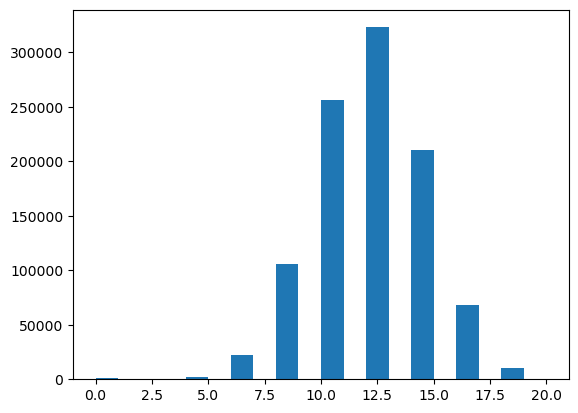

In [302]:
all_xors = all_xors[popcount(all_xors) == hamming_weight]
sample_xors = np.random.choice(all_xors, size=1000, replace=False)
plt.hist(popcount(sample_xors.reshape(-1, 1) ^ sample_xors.reshape(1, -1)).reshape(-1), bins=20)

In [322]:
distance = 14
for _ in range(1):
    selected_xors = similar_distance_network(
        all_xors, distance_min=distance, distance_max=distance + 2, maxitems=n_xors
    )
    if len(selected_xors) == n_xors:
        break
else:
    raise ValueError("Could not find enough xors")

ValueError: Could not find enough xors

In [323]:
len(selected_xors)

5